# Smart Retail Intelligence — Inventory AI Engine
### Member 3: ML / Inventory AI Developer

**Core Capabilities:**
1. **Stock-Out Prediction**: Supervised machine learning classifying future stock-out likelihood within replenishment lead-time.
2. **Inventory Anomaly Detection**: Discrepancy detection identifying phantom inventory, unrecorded shrinkage, and damaged stock.
3. **Stock Accuracy Risk Scoring**: Probabilistic confidence quantification of shelf reality vs ERP ledger counts.
4. **Demand-Aware Prioritization**: Revenue velocity and business impact scoring for task ranking.
5. **Replenishment Recommendations & Root-Cause Diagnostics**: Actionable operational recommendations (`REPLENISH`, `EXPEDITE`, `CYCLE_COUNT_AUDIT`, `MONITOR`, `NO_ACTION`).
6. **Agreed REST Ingestion**: Direct pipeline transmission to Java backend (`POST /api/v1/ingestion/inventory-risk`).

In [1]:
import sys
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add src to module search path
sys.path.insert(0, os.path.abspath('../src'))

from data_generator import generate_retail_dataset
from feature_engineering import extract_features
from stockout_predictor import StockoutPredictor, map_risk_level
from anomaly_detector import InventoryAnomalyDetector
from risk_scorer import InventoryRiskScorer
from replenishment_engine import ReplenishmentEngine
from pipeline import InventoryAIPipeline
from rest_client import BackendIngestionClient, MockBackendServer

print('Environment and AI modules successfully initialized.')

Environment and AI modules successfully initialized.


## 1. Realistic Retail Data Generation
Generates multi-category retail inventory data including seasonal demand, replenishment delays, manual adjustments, and shrinkage indicators.

In [2]:
df_raw = generate_retail_dataset(n_samples=1000, random_seed=42)
print(f'Total inventory records generated: {len(df_raw)}')
df_raw[['productId', 'productName', 'category', 'currentInventory', 'salesVelocity7d', 'replenishmentDelay', 'stockoutOccurred']].head(8)

Total inventory records generated: 1000


,productId,productName,category,currentInventory,salesVelocity7d,replenishmentDelay,stockoutOccurred
0,101,Organic Whole Milk 1L,Dairy & Fresh,14,28.0,5,1
1,102,Greek Yogurt 400g,Dairy & Fresh,2,12.6,5,1
2,103,Artisan Sourdough Bread,Bakery,17,17.0,5,1
3,104,Sparkling Spring Water 500ml,Beverages,193,16.9,1,0
4,105,Cold Pressed Orange Juice 1L,Beverages,27,12.4,6,1
5,106,Premium Arabica Coffee 250g,Packaged Foods,189,12.3,9,0
6,107,Organic Rolled Oats 1kg,Packaged Foods,156,22.0,4,0
7,108,Dark Chocolate Bar 70%,Snacks & Confectionery,174,20.4,12,0


## 2. Feature Engineering
Computes key operational retail features: Sales Velocity Ratios, Lead-Time Demand, Days of Supply, and Business Impact Scores.

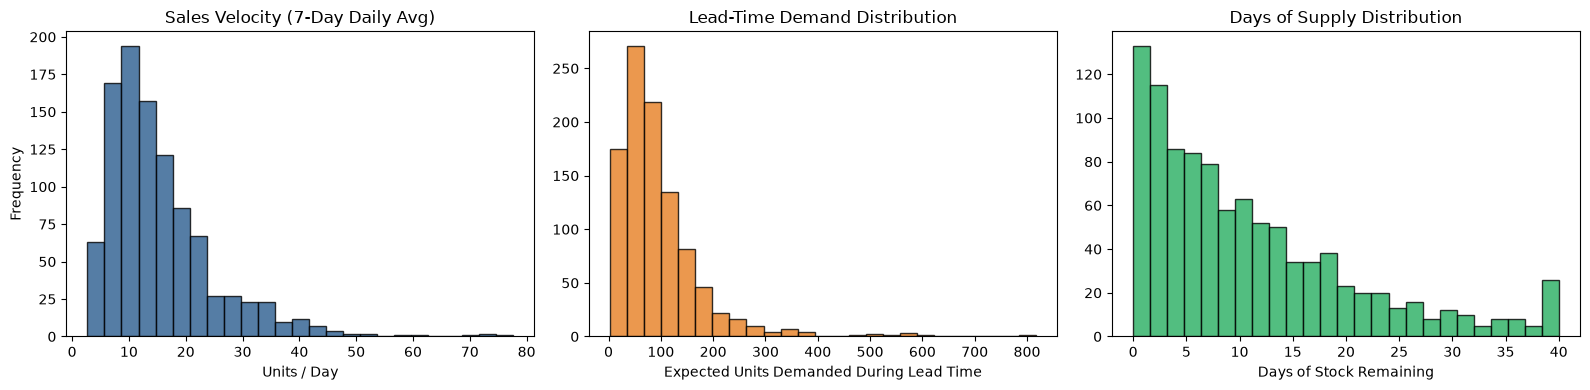

In [3]:
df_features = extract_features(df_raw)

# Visualization of operational distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_features['salesVelocity7d'], bins=25, color='#2b5c8f', edgecolor='black', alpha=0.8)
axes[0].set_title('Sales Velocity (7-Day Daily Avg)')
axes[0].set_xlabel('Units / Day')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_features['leadTimeDemand'], bins=25, color='#e67e22', edgecolor='black', alpha=0.8)
axes[1].set_title('Lead-Time Demand Distribution')
axes[1].set_xlabel('Expected Units Demanded During Lead Time')

axes[2].hist(df_features['daysOfSupply'].clip(upper=40), bins=25, color='#27ae60', edgecolor='black', alpha=0.8)
axes[2].set_title('Days of Supply Distribution')
axes[2].set_xlabel('Days of Stock Remaining')

plt.tight_layout()
plt.show()

## 3. Stock-Out Prediction Model
Trains a Random Forest classifier to predict stock-out probabilities within the replenishment window, applying calibrated risk level thresholds:
- `LOW`: $< 0.35$
- `MEDIUM`: $\ge 0.35$ and $< 0.65$
- `HIGH`: $\ge 0.65$ and $< 0.90$ (e.g. $0.87 \rightarrow \text{HIGH}$)
- `CRITICAL`: $\ge 0.90$

Model Training Performance: ROC-AUC = 0.9995


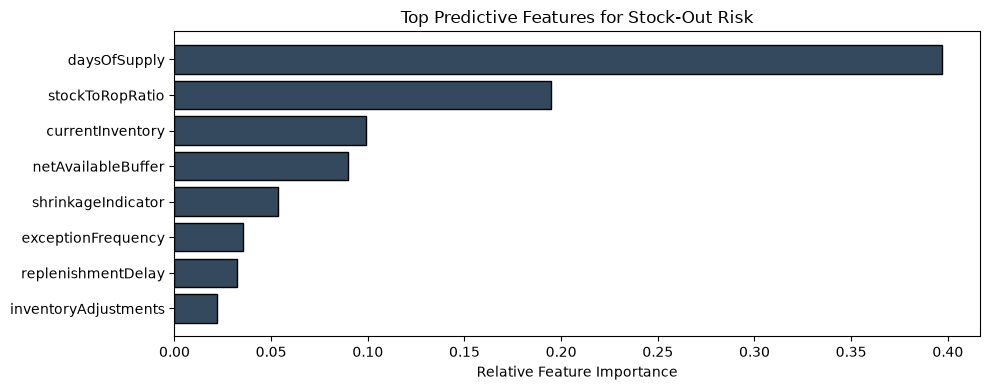

In [4]:
predictor = StockoutPredictor()
metrics = predictor.train(df_features)
print(f'Model Training Performance: ROC-AUC = {metrics["roc_auc"]}')

# Feature Importance Visualization
importances = predictor.get_feature_importances()
top_feats = list(importances.keys())[:8]
top_vals = [importances[k] for k in top_feats]

plt.figure(figsize=(10, 4))
plt.barh(top_feats[::-1], top_vals[::-1], color='#34495e', edgecolor='black')
plt.title('Top Predictive Features for Stock-Out Risk')
plt.xlabel('Relative Feature Importance')
plt.tight_layout()
plt.show()

## 4. Anomaly & Discrepancy Detection
Combines an unsupervised Isolation Forest with domain discrepancy rules to detect phantom stock (system shows inventory while physical shelf is empty), unrecorded shrinkage, and negative stock drift.

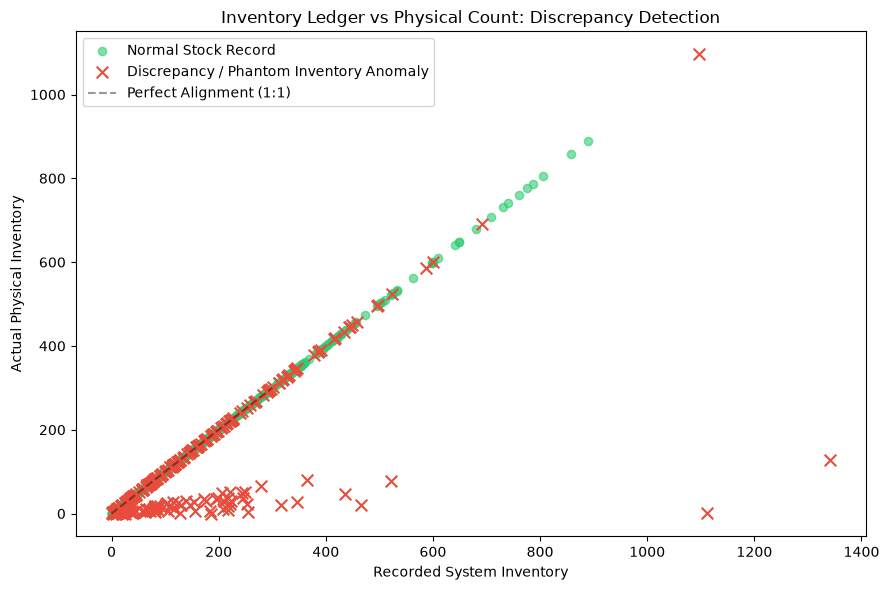

In [5]:
detector = InventoryAnomalyDetector()
detector.fit(df_features)

anomaly_results = detector.detect_batch(df_features)
df_features['isAnomalyDetected'] = [r['anomaly'] for r in anomaly_results]

# Scatter plot: Recorded Stock vs Physical Stock with Anomaly highlights
plt.figure(figsize=(9, 6))
normal_mask = ~df_features['isAnomalyDetected']
anom_mask = df_features['isAnomalyDetected']

plt.scatter(df_features.loc[normal_mask, 'currentInventory'], df_features.loc[normal_mask, 'physicalInventory'],
            c='#2ecc71', alpha=0.6, label='Normal Stock Record', s=35)
plt.scatter(df_features.loc[anom_mask, 'currentInventory'], df_features.loc[anom_mask, 'physicalInventory'],
            c='#e74c3c', marker='x', s=70, label='Discrepancy / Phantom Inventory Anomaly')

plt.plot([0, 300], [0, 300], 'k--', alpha=0.4, label='Perfect Alignment (1:1)')
plt.title('Inventory Ledger vs Physical Count: Discrepancy Detection')
plt.xlabel('Recorded System Inventory')
plt.ylabel('Actual Physical Inventory')
plt.legend()
plt.tight_layout()
plt.show()

## 5. End-to-End AI Pipeline & Agreed 5-Field JSON Serialization
Executes the full pipeline and inspects the exact agreed 5-field schema output.

In [6]:
pipeline = InventoryAIPipeline()
pipeline.ensure_ready()

# Run inference on sample set
test_sample = df_raw.head(5)
agreed_output = pipeline.run_inference(test_sample, enriched=False)

print('Agreed 5-Field JSON Output for Java Ingestion:')
print(json.dumps(agreed_output, indent=2))

Agreed 5-Field JSON Output for Java Ingestion:
[
  {
    "productId": 101,
    "stockoutProbability": 0.99,
    "riskLevel": "CRITICAL",
    "anomaly": true,
    "recommendedAction": "REPLENISH"
  },
  {
    "productId": 102,
    "stockoutProbability": 0.99,
    "riskLevel": "CRITICAL",
    "anomaly": true,
    "recommendedAction": "REPLENISH"
  },
  {
    "productId": 103,
    "stockoutProbability": 0.99,
    "riskLevel": "CRITICAL",
    "anomaly": false,
    "recommendedAction": "REPLENISH"
  },
  {
    "productId": 104,
    "stockoutProbability": 0.03,
    "riskLevel": "LOW",
    "anomaly": false,
    "recommendedAction": "NO_ACTION"
  },
  {
    "productId": 105,
    "stockoutProbability": 0.99,
    "riskLevel": "CRITICAL",
    "anomaly": false,
    "recommendedAction": "REPLENISH"
  }
]


## 6. Simulated REST Dispatch to Java Backend
Demonstrates direct API transmission to `POST /api/v1/ingestion/inventory-risk` using the built-in mock backend server.

In [7]:
# Launch local mock server to verify HTTP contract
import time
mock_server = MockBackendServer(port=8080)
mock_server.start()
time.sleep(0.5)

try:
    client = BackendIngestionClient(base_url='http://127.0.0.1:8080')
    summary = client.send_batch(agreed_output, item_by_item=True)
    print(f'REST Dispatch Status: {summary["successful"]} / {summary["total"]} payloads ingested successfully.')
    
    # Inspect what the backend received
    received = mock_server.get_received()
    print(f'Backend successfully verified receipt of {len(received)} items.')
    print('Sample verified item at backend:', json.dumps(received[0], indent=2))
finally:
    mock_server.stop()

2026-09-07 00:48:54,907 [INFO] Mock Java Backend Server listening on http://127.0.0.1:8080/api/v1/ingestion/inventory-risk


2026-09-07 00:48:55,425 [INFO] POST http://127.0.0.1:8080/api/v1/ingestion/inventory-risk -> Status: 200 for productId 101 (attempt 1/2)


2026-09-07 00:48:55,441 [INFO] POST http://127.0.0.1:8080/api/v1/ingestion/inventory-risk -> Status: 200 for productId 102 (attempt 1/2)


2026-09-07 00:48:55,456 [INFO] POST http://127.0.0.1:8080/api/v1/ingestion/inventory-risk -> Status: 200 for productId 103 (attempt 1/2)


2026-09-07 00:48:55,472 [INFO] POST http://127.0.0.1:8080/api/v1/ingestion/inventory-risk -> Status: 200 for productId 104 (attempt 1/2)


2026-09-07 00:48:55,475 [INFO] POST http://127.0.0.1:8080/api/v1/ingestion/inventory-risk -> Status: 200 for productId 105 (attempt 1/2)


REST Dispatch Status: 5 / 5 payloads ingested successfully.
Backend successfully verified receipt of 5 items.
Sample verified item at backend: {
  "productId": 101,
  "stockoutProbability": 0.99,
  "riskLevel": "CRITICAL",
  "anomaly": true,
  "recommendedAction": "REPLENISH"
}


2026-09-07 00:48:55,987 [INFO] Mock Java Backend Server stopped.
